# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores



# Base de dados:

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.






**WebPurchases: Número de compras feitas pelo site da empresa.**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split


# ETAPA 1:

**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

In [6]:
base = pd.read_csv('marketing_campaign.csv', delimiter=';')

In [7]:
base

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,46,709,43,182,42,118,247,4,5,0,1
2236,1946,PhD,Together,64014.0,2,56,406,0,30,0,0,8,5,7,0,1
2237,1981,Graduation,Divorced,56981.0,0,91,908,48,217,32,12,24,13,6,0,0
2238,1956,Master,Together,69245.0,0,8,428,30,214,80,30,61,10,3,0,1


In [8]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   str    
 2   Marital_Status     2240 non-null   str    
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13), str(2)
me

In [9]:
# 24 dados "nulos" ou faltantes
base['Income'].isna().sum()

np.int64(24)

In [10]:
# ferifiquei as linas que estavam faltando no Income
base[base['Income'].isna()]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
10,1983,Graduation,Married,NaN,1,11,5,5,6,0,2,1,2,7,0,0
27,1986,Graduation,Single,NaN,1,19,5,1,3,3,263,362,0,1,0,1
43,1959,PhD,Single,NaN,0,80,81,11,50,3,2,39,4,2,0,0
48,1951,Graduation,Single,NaN,2,96,48,5,48,6,10,7,4,6,0,0
58,1982,Graduation,Single,NaN,1,57,11,3,22,2,2,6,3,6,0,0
71,1973,2n Cycle,Married,NaN,1,25,25,3,43,17,4,17,3,8,0,0
90,1957,PhD,Married,NaN,2,4,230,42,192,49,37,53,8,9,0,1
91,1957,Graduation,Single,NaN,1,45,7,0,8,2,0,1,2,7,0,0
92,1973,Master,Together,NaN,0,87,445,37,359,98,28,18,8,1,0,0
128,1961,PhD,Married,NaN,0,23,352,0,27,10,0,15,7,6,0,1


In [11]:
# gostaria de inspecionar quais o valores que estao sendo impressos nessas colunas
# analisar se nao tem nenhum dado absurdo
for col in ['Education', 'Marital_Status', 'Complain', 'WebPurchases']:
    print('\n', col)
    print(base[col].value_counts())


 Education
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

 Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

 Complain
Complain
0    2219
1      21
Name: count, dtype: int64

 WebPurchases
WebPurchases
1    1128
0    1112
Name: count, dtype: int64


In [12]:
base.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,5.790179,5.316518,0.009375,0.503571
std,11.984069,25173.076661,0.538398,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,3.250958,2.426645,0.096391,0.500099
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68522.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,13.000000,20.000000,1.000000,1.000000


In [13]:
# visao geral do database
print('Linhas, colunas:', base.shape)
print('\nDuplicados:', base.duplicated().sum())
print('\nValores faltantes:')
print(base.isna().sum())

Linhas, colunas: (2240, 16)

Duplicados: 201

Valores faltantes:
Year_Birth            0
Education             0
Marital_Status        0
Income               24
Kidhome               0
Recency               0
MntWines              0
MntFruits             0
MntMeatProducts       0
MntFishProducts       0
MntSweetProducts      0
MntGoldProds          0
NumStorePurchases     0
NumWebVisitsMonth     0
Complain              0
WebPurchases          0
dtype: int64


In [14]:
# confirmacao de duplicacao
print('Excedentes:', base.duplicated().sum())
print('Total em grupos duplicados:', base[base.duplicated(keep=False)].shape[0])

Excedentes: 201
Total em grupos duplicados: 394


Foram identificados 201 linhas duplicadas. Entretaanto como a passe nao possui ID unico, nao é possivel garantir qeu estas linhas sejam erros de cadastro.
Estas repetições podem representar clientes distintos, entao optei por manter essa parte de base e não exclui-la. pois representaria quase 10% de toda a base perdida neste caso.

In [15]:
# tratando os dados faltantes de Income - NaN. Neste caso prerimos imputar a mediana nestes casos
# Assim não é necessário excluir estes dados
base['Income'] = base['Income'].fillna(base['Income'].median())

In [16]:
# proxima etape é verificacao de outliers e visualizaçao grafica
colunas_numericas = [
    'Year_Birth', 'Income', 'Kidhome', 'Recency', 'MntWines',
    'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumStorePurchases', 'NumWebVisitsMonth'
]

for col in colunas_numericas:
    q1 = base[col].quantile(0.25)
    q3 = base[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    qtd = base[(base[col] < limite_inferior) | (base[col] > limite_superior)].shape[0]

    print(f'\n{col}')
    print(f'Q1: {q1}')
    print(f'Q3: {q3}')
    print(f'IQR: {iqr}')
    print(f'Limite inferior: {limite_inferior}')
    print(f'Limite superior: {limite_superior}')
    print(f'Quantidade de outliers: {qtd}')




Year_Birth
Q1: 1959.0
Q3: 1977.0
IQR: 18.0
Limite inferior: 1932.0
Limite superior: 2004.0
Quantidade de outliers: 3

Income
Q1: 35538.75
Q3: 68289.75
IQR: 32751.0
Limite inferior: -13587.75
Limite superior: 117416.25
Quantidade de outliers: 8

Kidhome
Q1: 0.0
Q3: 1.0
IQR: 1.0
Limite inferior: -1.5
Limite superior: 2.5
Quantidade de outliers: 0

Recency
Q1: 24.0
Q3: 74.0
IQR: 50.0
Limite inferior: -51.0
Limite superior: 149.0
Quantidade de outliers: 0

MntWines
Q1: 23.75
Q3: 504.25
IQR: 480.5
Limite inferior: -697.0
Limite superior: 1225.0
Quantidade de outliers: 35

MntFruits
Q1: 1.0
Q3: 33.0
IQR: 32.0
Limite inferior: -47.0
Limite superior: 81.0
Quantidade de outliers: 227

MntMeatProducts
Q1: 16.0
Q3: 232.0
IQR: 216.0
Limite inferior: -308.0
Limite superior: 556.0
Quantidade de outliers: 175

MntFishProducts
Q1: 3.0
Q3: 50.0
IQR: 47.0
Limite inferior: -67.5
Limite superior: 120.5
Quantidade de outliers: 223

MntSweetProducts
Q1: 1.0
Q3: 33.0
IQR: 32.0
Limite inferior: -47.0
Limite 

In [21]:
# anos abaixo de 1932
year_menos_q1 = base['Year_Birth'] < 1932
base[year_menos_q1]


,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
192,1900,2n Cycle,Divorced,36640.0,1,99,15,6,8,7,4,25,2,5,1,0
239,1893,2n Cycle,Single,60182.0,0,23,8,0,5,7,0,2,2,4,0,0
339,1899,PhD,Together,83532.0,0,36,755,144,562,104,64,224,4,1,0,1


In [22]:
# vale a pena limpar estes 3 registros pois estes anos de nascimento são bem pouco provaveis
base = base[base['Year_Birth'] >= 1932].copy()

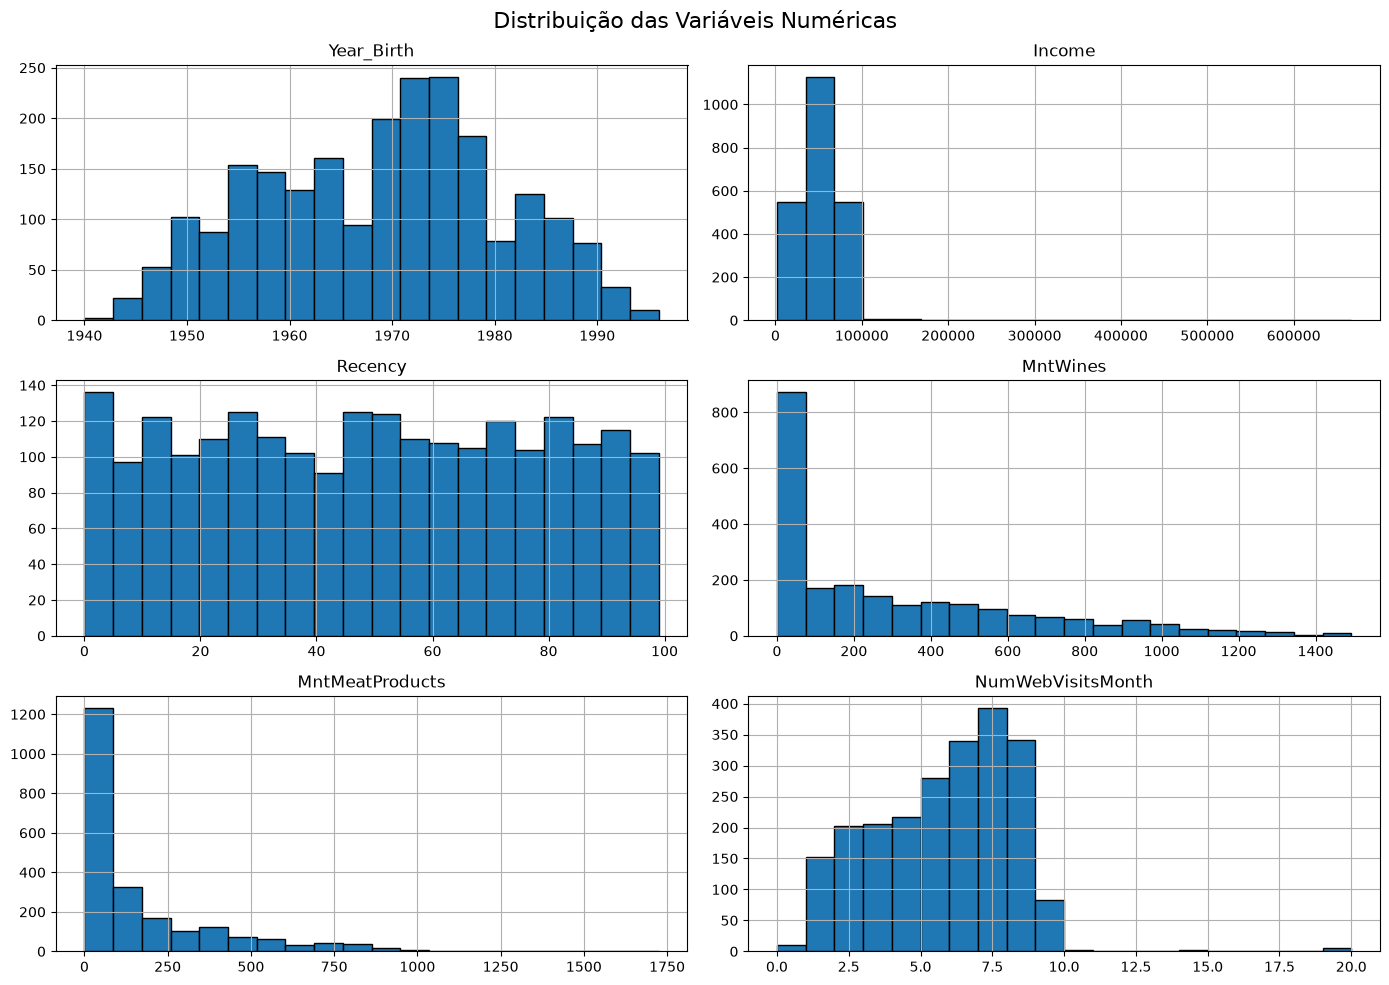

In [24]:
# algumas variaveis de consumo apresentam assimetria a direita, indicando clientes com gastos muito acima da maioria

colunas_numericas = [
    'Year_Birth', 'Income', 'Recency',
    'MntWines', 'MntMeatProducts', 'NumWebVisitsMonth'
]

base[colunas_numericas].hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=16)
plt.tight_layout()
plt.show()

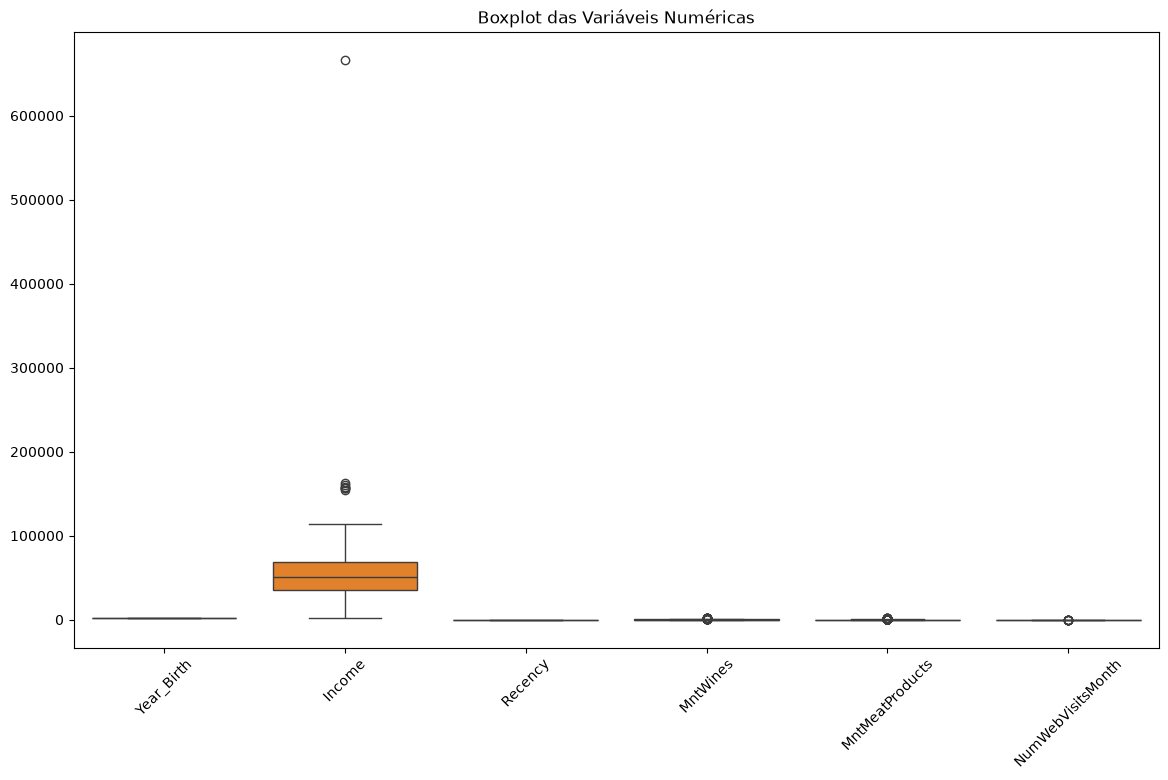

In [25]:
# Os boxplots confirmam a presença de valores extremos em variáveis de consumo e renda. 
# Como esses valores podem representar clientes reais de alto valor, eles não foram removidos automaticamente.
plt.figure(figsize=(14, 8))
sns.boxplot(data=base[colunas_numericas])
plt.title('Boxplot das Variáveis Numéricas')
plt.xticks(rotation=45)
plt.show()


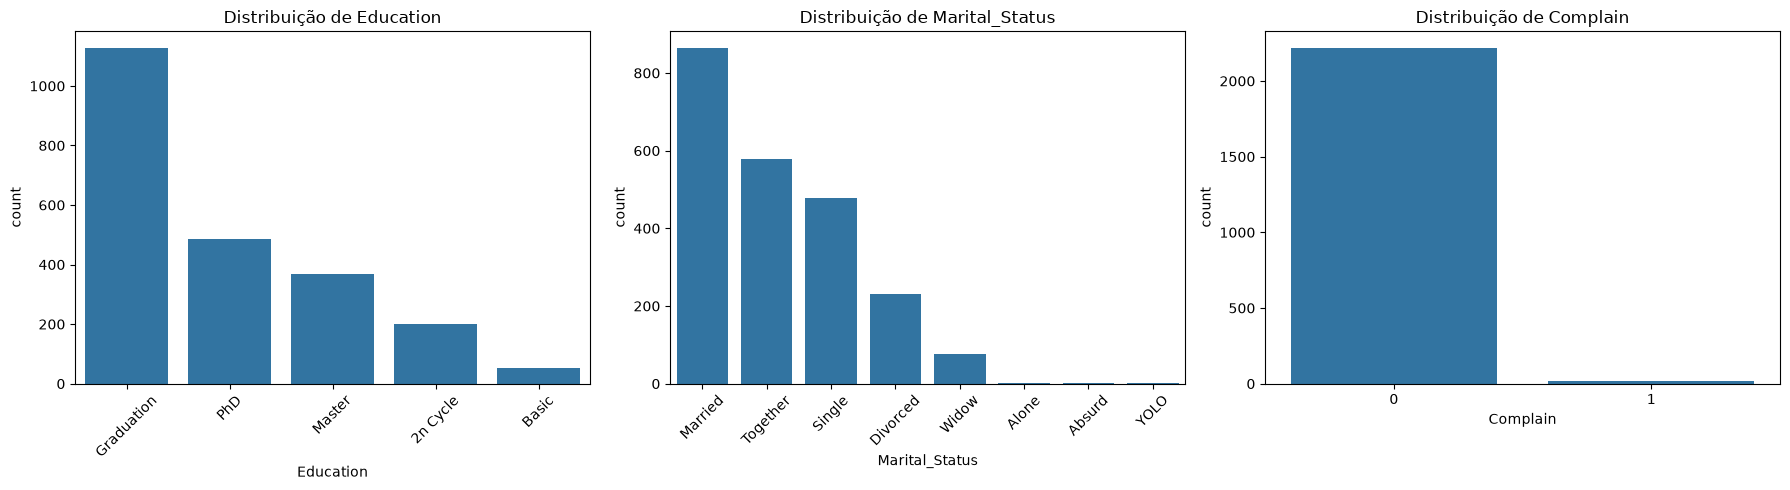

In [26]:
# Esse gráfico permite entender o perfil categórico dos clientes.
# Identificando categorias predominantes em escolaridade, estado civil e reclamações.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=base, x='Education', ax=axes[0], order=base['Education'].value_counts().index)
axes[0].set_title('Distribuição de Education')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=base, x='Marital_Status', ax=axes[1], order=base['Marital_Status'].value_counts().index)
axes[1].set_title('Distribuição de Marital_Status')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=base, x='Complain', ax=axes[2], order=base['Complain'].value_counts().index)
axes[2].set_title('Distribuição de Complain')

plt.tight_layout()
plt.show()

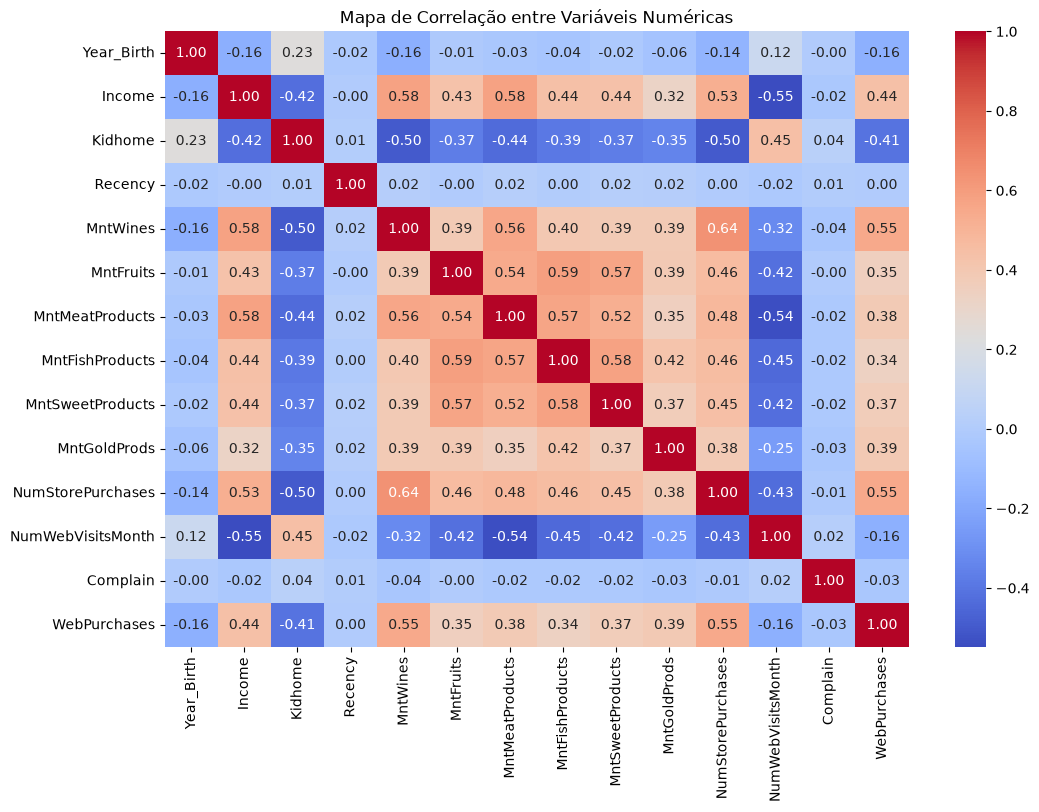

In [27]:
# O mapa de correlação ajuda a identificar relações entre variáveis numéricas e sugere possíveis agrupamentos de comportamento.
# O que é útil para etapas posteriores como padronização e PCA.

plt.figure(figsize=(12, 8))
corr = base.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Correlação entre Variáveis Numéricas')
plt.show()

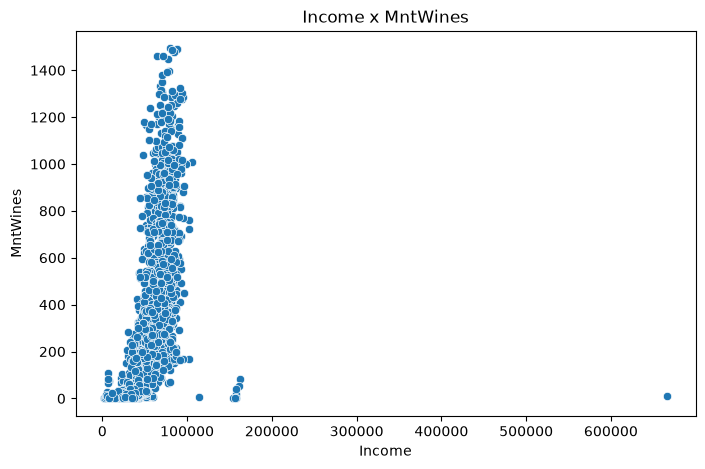

In [28]:
# Os scatterplots ajudam a avaliar se clientes com maior renda tendem a apresentar maior consumo.
# Além de permitir observar padrões entre visitas ao site e compras realizadas.

plt.figure(figsize=(8, 5))
sns.scatterplot(data=base, x='Income', y='MntWines')
plt.title('Income x MntWines')
plt.show()

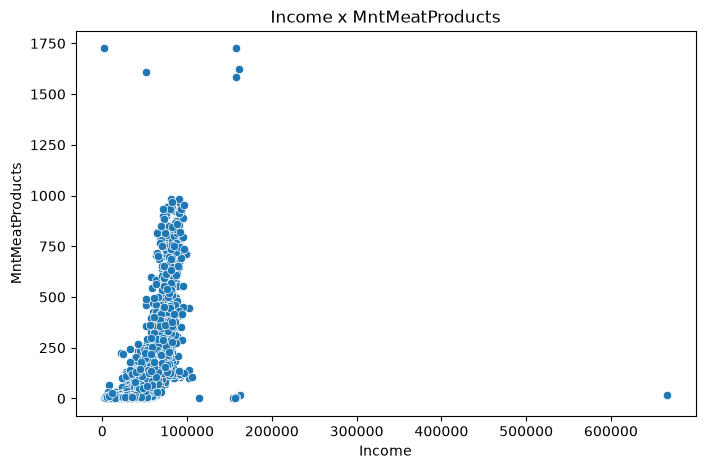

In [29]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=base, x='Income', y='MntMeatProducts')
plt.title('Income x MntMeatProducts')
plt.show()

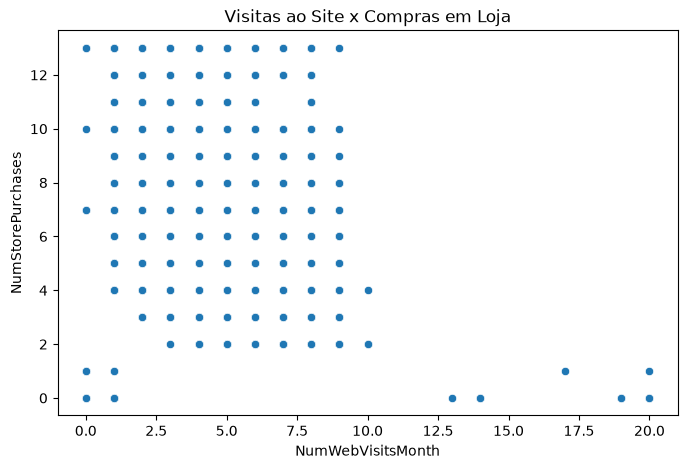

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=base, x='NumWebVisitsMonth', y='NumStorePurchases')
plt.title('Visitas ao Site x Compras em Loja')
plt.show()

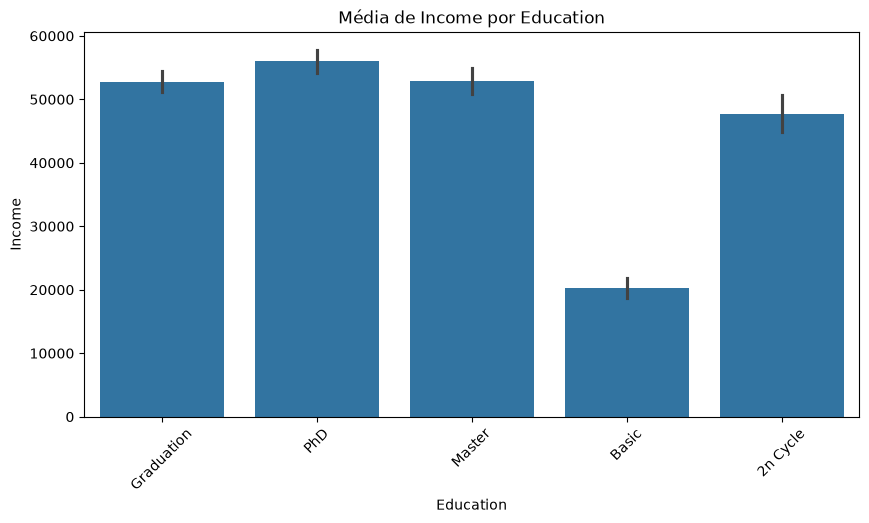

In [31]:
# As médias por categoria ajudam a identificar diferenças de perfil entre grupos de clientes.
# O que pode ser relevante para segmentação posterior.

plt.figure(figsize=(10, 5))
sns.barplot(data=base, x='Education', y='Income', estimator='mean')
plt.title('Média de Income por Education')
plt.xticks(rotation=45)
plt.show()

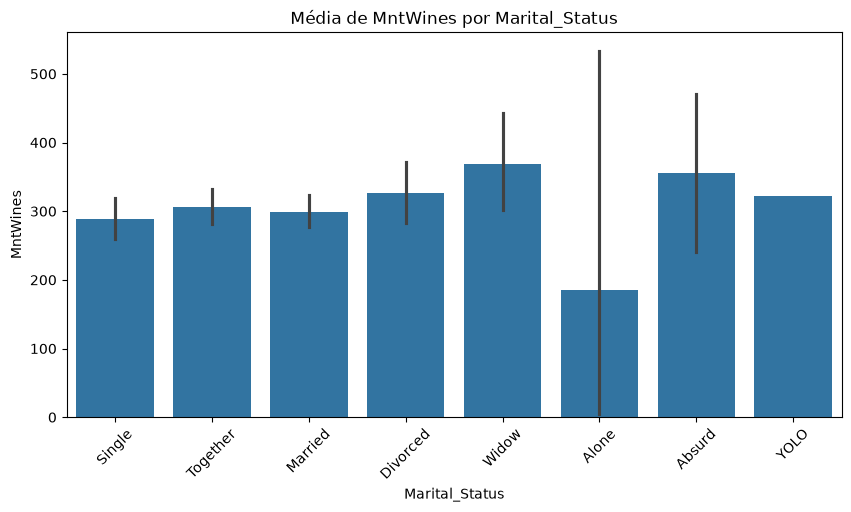

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(data=base, x='Marital_Status', y='MntWines', estimator='mean')
plt.title('Média de MntWines por Marital_Status')
plt.xticks(rotation=45)
plt.show()

Após a etapa de exploração, limpeza e análise gráfica, a base apresentou distribuição assimétrica em algumas variáveis de consumo e renda, além de outliers que, após inspeção, foram considerados plausíveis e mantidos. Também foram identificados e removidos registros com ano de nascimento implausível. Com isso, a base está pronta para a próxima etapa de pré-processamento, incluindo tratamento de variáveis categóricas, padronização e aplicação de PCA.

# ETAPA 2:
**Pré-processamento**

**Análise Correlação:** Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

**Codificação de Variáveis Categóricas:** Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.


**Separe a base em Y, X e Treino e teste:**: Faça a separação da base.

**Realize a padronização dos dados**: Padronize os dados para garantir eficiência no modelo e eficácia.








In [33]:
# Separacao de vriaveis que vao entrar no PCA
# definicao de colunas

colunas_numericas = [
    'Year_Birth', 'Income', 'Kidhome', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumStorePurchases', 'NumWebVisitsMonth'
]

colunas_categoricas = [
    'Education', 'Marital_Status', 'Complain'
]

In [34]:
# criaçao de um recorte d ebase
base_pca = base[ colunas_numericas + colunas_categoricas].copy()
base_pca.head()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Education,Marital_Status,Complain
0,1957,58138.0,0,58,635,88,546,172,88,88,4,7,Graduation,Single,0
1,1954,46344.0,1,38,11,1,6,2,1,6,2,5,Graduation,Single,0
2,1965,71613.0,0,26,426,49,127,111,21,42,10,4,Graduation,Together,0
3,1984,26646.0,1,26,11,4,20,10,3,5,4,6,Graduation,Together,0
4,1981,58293.0,1,94,173,43,118,46,27,15,6,5,PhD,Married,0


In [ ]:
# Conferencia da limpeza e selecao de variaveis
print(base_pca.shape)
print(base_pca.dtypes)
print(base_pca.isna().sum())

(2237, 15)
Year_Birth             int64
Income               float64
Kidhome                int64
Recency                int64
MntWines               int64
MntFruits              int64
MntMeatProducts        int64
MntFishProducts        int64
MntSweetProducts       int64
MntGoldProds           int64
NumStorePurchases      int64
NumWebVisitsMonth      int64
Education                str
Marital_Status           str
Complain               int64
dtype: object
Year_Birth           0
Income               0
Kidhome              0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumStorePurchases    0
NumWebVisitsMonth    0
Education            0
Marital_Status       0
Complain             0
dtype: int64


Nesta etapa, foram selecionadas as variáveis numéricas e categóricas mais relevantes para a análise. As variáveis numéricas serão utilizadas diretamente após padronização, enquanto as categóricas passarão por transformação para formato numérico antes da aplicação do PCA.

In [36]:
# encoding -  conversao de categoricas para numericas
base_pca = pd.get_dummies(base_pca, columns=colunas_categoricas,drop_first=True)
base_pca.head()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Complain_1
0,1957,58138.0,0,58,635,88,546,172,88,88,...,False,False,False,False,False,True,False,False,False,False
1,1954,46344.0,1,38,11,1,6,2,1,6,...,False,False,False,False,False,True,False,False,False,False
2,1965,71613.0,0,26,426,49,127,111,21,42,...,False,False,False,False,False,False,True,False,False,False
3,1984,26646.0,1,26,11,4,20,10,3,5,...,False,False,False,False,False,False,True,False,False,False
4,1981,58293.0,1,94,173,43,118,46,27,15,...,False,True,False,False,True,False,False,False,False,False


In [37]:
print(base_pca.shape)
print(base_pca.dtypes)

(2237, 24)
Year_Birth                   int64
Income                     float64
Kidhome                      int64
Recency                      int64
MntWines                     int64
MntFruits                    int64
MntMeatProducts              int64
MntFishProducts              int64
MntSweetProducts             int64
MntGoldProds                 int64
NumStorePurchases            int64
NumWebVisitsMonth            int64
Education_Basic               bool
Education_Graduation          bool
Education_Master              bool
Education_PhD                 bool
Marital_Status_Alone          bool
Marital_Status_Divorced       bool
Marital_Status_Married        bool
Marital_Status_Single         bool
Marital_Status_Together       bool
Marital_Status_Widow          bool
Marital_Status_YOLO           bool
Complain_1                    bool
dtype: object


In [38]:
# conversao dos boleanos
base_pca = base_pca.astype(int)

In [40]:
# padronizacao dos dados
scaler = StandardScaler()
base_pca_scaled = scaler.fit_transform(base_pca)
base_pca_scaled[:5]

array([[-1.01729612e+00,  2.36068210e-01, -8.25388397e-01,
         3.07271794e-01,  9.83671059e-01,  1.55462269e+00,
         1.68025330e+00,  2.46169964e+00,  1.47587679e+00,
         8.46061170e-01, -5.52076889e-01,  6.92881788e-01,
        -1.57278737e-01,  9.92429194e-01, -4.45172884e-01,
        -5.26143026e-01, -3.66453643e-02, -3.39344274e-01,
        -7.93271045e-01,  1.91576255e+00, -5.90944941e-01,
        -1.88807172e-01, -2.99141202e-02, -9.49799969e-02],
       [-1.27372169e+00, -2.34982033e-01,  1.03215068e+00,
        -3.83584031e-01, -8.70717011e-01, -6.36421588e-01,
        -7.13250050e-01, -6.50274951e-01, -6.31440473e-01,
        -7.29568637e-01, -1.16742119e+00, -1.31573829e-01,
        -1.57278737e-01,  9.92429194e-01, -4.45172884e-01,
        -5.26143026e-01, -3.66453643e-02, -3.39344274e-01,
        -7.93271045e-01,  1.91576255e+00, -5.90944941e-01,
        -1.88807172e-01, -2.99141202e-02, -9.49799969e-02],
       [-3.33494613e-01,  7.74257291e-01, -8.25388397e

Após a transformação das variáveis categóricas, os dados foram padronizados com StandardScaler. Essa etapa é fundamental para o PCA, pois garante que todas as variáveis contribuam de forma equilibrada, independentemente de sua escala original.

In [42]:
# aplicando PCA e usando o fit_transform para aprender a estrutura de dados padronizados
pca = PCA()
componetes_pca = pca.fit_transform(base_pca_scaled)
print(componetes_pca.shape)

(2237, 24)


In [43]:
# mostra a variancia de cada componente  e quanto o conjunto total explica
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[2.15239631e-01 7.54250239e-02 6.29566899e-02 5.65821223e-02
 5.34607712e-02 4.99692430e-02 4.56612342e-02 4.48711459e-02
 4.36637241e-02 4.18494922e-02 4.08460879e-02 3.93592274e-02
 3.61712406e-02 3.34926187e-02 2.86625670e-02 2.45929750e-02
 2.25681464e-02 1.89923245e-02 1.80979310e-02 1.66969536e-02
 1.46849879e-02 1.06456089e-02 5.46011883e-03 5.01344766e-05]
1.0


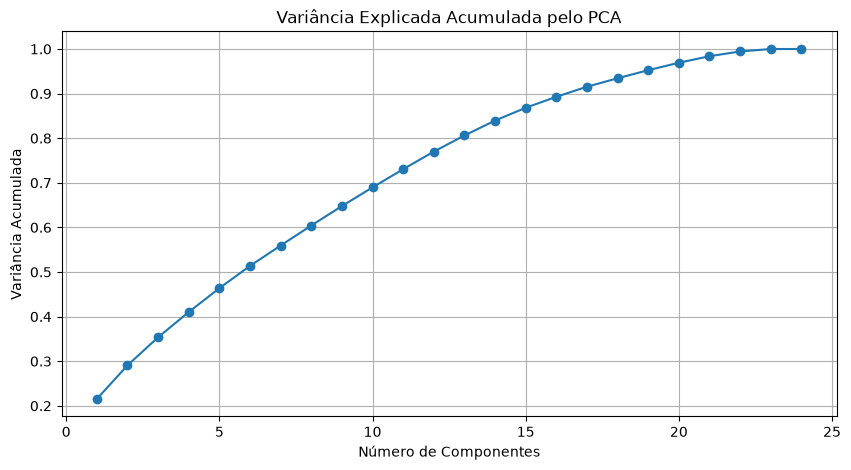

In [45]:
# visualizacao visual 

variancia_explicada = pca.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Acumulada')
plt.title('Variância Explicada Acumulada pelo PCA')
plt.grid(True)
plt.show()

Após a padronização, foi aplicado o PCA para reduzir a dimensionalidade da base. Em seguida, foi analisada a variância explicada por cada componente principal e a variância acumulada, com o objetivo de definir quantos componentes preservam a maior parte da informação original.

In [47]:
# 13 componets mostram 80% de variancia
pca_final = PCA(n_components=13)
componetes_final = pca_final.fit_transform(base_pca_scaled)

colunas_pca = [f'PC{i+1}' for i in range(13)]
pca_df = pd.DataFrame(componetes_final, columns=colunas_pca)

print(pca_df.shape)
pca_df.head()

(2237, 13)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,2.932847,1.744693,-0.846021,1.294081,-0.677288,0.379648,0.667977,-0.059751,-0.035468,-0.019096,-0.188895,0.226877,-0.354832
1,-1.904591,0.959768,-0.886284,0.792661,-1.059250,0.641459,0.776717,-0.998263,-0.510997,0.003690,-0.585308,-0.535404,-0.563129
2,1.792771,0.558406,-1.290643,-1.338352,0.309675,-0.873241,-0.162337,-0.020824,-0.753385,-0.095001,-0.130227,-0.730798,-0.588528
3,-2.163179,1.309521,-1.225180,-0.906427,0.551688,-1.162007,-0.517178,0.023726,-0.652468,0.103017,-0.251782,-0.746338,0.613459
4,-0.434132,-0.947010,1.656408,0.628800,-0.255388,-1.370184,-0.292271,-0.269634,1.412112,0.446315,0.098448,0.844250,1.561849


In [48]:
print('Variância total explicada:', pca_final.explained_variance_ratio_.sum())

Variância total explicada: 0.8060556337616742


Com base no gráfico de variância acumulada, foram selecionados 13 componentes principais, capazes de explicar aproximadamente 80% da variância total dos dados. Essa escolha permite reduzir a dimensionalidade da base preservando a maior parte da informação original.

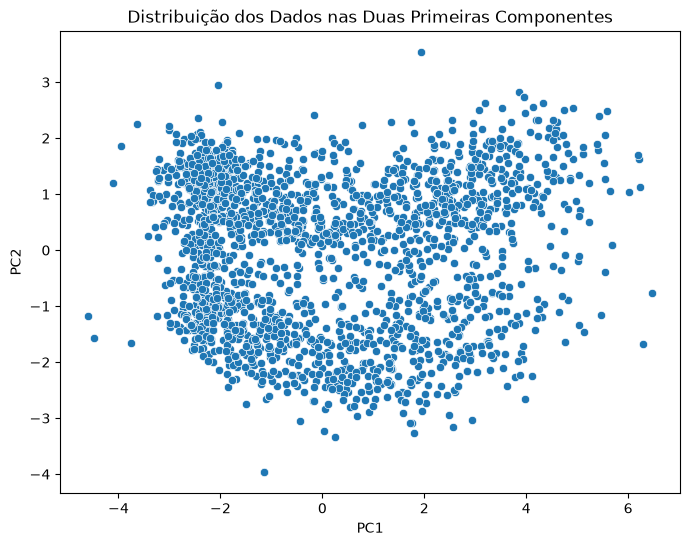

In [49]:
# distribuicao grafica do PC1 x PC2
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2')
plt.title('Distribuição dos Dados nas Duas Primeiras Componentes')
plt.show()

O gráfico entre PC1 e PC2 foi utilizado por ser a forma mais simples de visualizar os dados em duas dimensões. Essas duas componentes concentram a maior parcela de variância individual, embora não representem toda a informação preservada pelo PCA. Portanto, essa visualização deve ser interpretada como uma projeção simplificada da estrutura dos dados.

In [ ]:
y = base['WebPurchases']

In [51]:
x = base.drop(columns='WebPurchases')

In [ ]:
#apesar dos dados estarem bem balanceados coloquei o stratify como params
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

As variáveis categóricas foram convertidas em colunas numéricas com pd.get_dummies(). Depois, as bases de treino e teste foram alinhadas para garantir que ambas tivessem as mesmas colunas, evitando problemas nas etapas seguintes do modelo.

In [56]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [58]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [59]:
pca_final = PCA(n_components=13)
x_train_pca = pca_final.fit_transform(x_train_scaled)
x_test_pca = pca_final.transform(x_test_scaled)

In [60]:
# checagem de dados
print(x_train_pca.shape)
print(x_test_pca.shape)
print(pca_final.explained_variance_ratio_.sum())

(1565, 13)
(672, 13)
0.802099953427877


Após a padronização, foi aplicado o PCA mantendo 13 componentes principais. O ajuste foi realizado apenas na base de treino, e a mesma transformação foi aplicada na base de teste, preservando a consistência do processo e evitando vazamento de dados.

# ETAPA 3:

**Modelagem**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

In [19]:
# seu código aqui

# ETAPA 4:

**Avaliação**

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões.

Utilize além das métricas padrões a matriz de confusão.

In [20]:
# seu código aqui